En este notebook se construye una capa final de priorización de riesgo a partir de los resultados obtenidos en los notebooks anteriores.

El objetivo no es volver a entrenar un detector de anomalías, sino ordenar los segmentos AIS detectados o caracterizados previamente según su nivel de riesgo operativo. Para ello se combinan las señales procedentes de modelos no supervisados, reglas marítimas expertas y resultados de clustering.

Además, se introduce un identificador global de trayectoria (`trajectory_global`) para garantizar la trazabilidad de cada segmento respecto a la trayectoria original de la embarcación.

## Imports

In [3]:
import os
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Carga de datos



In [4]:
import os
import shutil

if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')
    print("Carpeta /content/drive eliminada")

from google.colab import drive
drive.mount('/content/drive')

Carpeta /content/drive eliminada
Mounted at /content/drive


In [28]:
BASE_PATH = "/content/drive/MyDrive/TFG"

DATA_PATH = os.path.join(
    BASE_PATH,
    "results",
    "ranking",
    "ranking_input_v2.csv"
)

OUTPUT_DIR = os.path.join(BASE_PATH, "results", "risk_ranking")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Input file:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Input file: /content/drive/MyDrive/TFG/results/ranking/ranking_input_v2.csv
Output directory: /content/drive/MyDrive/TFG/results/risk_ranking


In [29]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)


Shape: (29141, 32)


In [30]:
display(df.head())


,MMSI,trajectory_id,segment_id,ae_score,lof_score,hybrid_score,hybrid_score_norm,rule_score_raw,rule_score_norm,potential_real_anomaly,is_synthetic,anomaly_type,ship_type,hybrid_context_pred,cluster_kmeans,cluster_hdbscan,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag,risk_proxy,risk_label
0,367689040,1,923622,0.000082,1.071137,0.060992,0.096090,2.5,0.304878,NaN,0,normal,Service,0,NaN,NaN,9.985714,10.6,9.833333,17.0,0.089193,0.175000,7.166667,3.942684,759.000000,2.615385,0,0,0,0,0.170827,2
1,368161380,0,1170073,1.062951,3.388275,0.263889,0.415745,1.0,0.121951,0.0,1,speed_anomaly,Special_Craft,1,0.0,-1.0,0.000000,0.0,4.775000,19.1,0.026528,0.106111,14.325000,0.003446,720.000000,1.000000,1,1,1,0,0.200389,2
2,366838630,1,370317,0.000492,1.021555,0.126938,0.199985,5.2,0.634146,0.0,0,normal,Passenger,1,6.0,4.0,0.033333,0.1,87.162500,177.2,1.173742,2.568116,90.037500,0.000000,691.000000,3.501326,1,0,1,1,0.355360,3
3,367030830,6,505747,0.000468,1.004585,0.053762,0.084699,2.2,0.268293,NaN,0,normal,Special_Craft,0,NaN,NaN,0.057143,0.1,60.169231,174.4,1.080410,3.571429,114.230769,20.507550,859.000000,1.341227,1,0,0,1,0.150376,1
4,367480130,0,730307,0.150122,298.980127,0.033823,0.053286,0.0,0.000000,NaN,1,loitering_like,Special_Craft,0,NaN,NaN,0.000000,0.0,6.375000,10.4,0.035485,0.058101,4.025000,0.002199,1220.558226,1.016667,1,0,1,0,0.018650,0


In [31]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29141 entries, 0 to 29140
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MMSI                    29141 non-null  int64  
 1   trajectory_id           29141 non-null  int64  
 2   segment_id              29141 non-null  int64  
 3   ae_score                29141 non-null  float64
 4   lof_score               29141 non-null  float64
 5   hybrid_score            29141 non-null  float64
 6   hybrid_score_norm       29141 non-null  float64
 7   rule_score_raw          29141 non-null  float64
 8   rule_score_norm         29141 non-null  float64
 9   potential_real_anomaly  7394 non-null   float64
 10  is_synthetic            29141 non-null  int64  
 11  anomaly_type            29141 non-null  object 
 12  ship_type               29141 non-null  object 
 13  hybrid_context_pred     29141 non-null  int64  
 14  cluster_kmeans          7394 non-null 

None

In [32]:
required_cols = [
    "MMSI",
    "trajectory_id",
    "hybrid_score",
    "rule_score_norm",
    "cluster_kmeans"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")
else:
    print("Todas las columnas necesarias están presentes.")

Todas las columnas necesarias están presentes.


Creamos `trajectory_global`

In [33]:
df["trajectory_global"] = (
    df["MMSI"].astype(str) + "_" + df["trajectory_id"].astype(str)
)

print("Número de segmentos:", len(df))
print("Número de MMSI únicos:", df["MMSI"].nunique())
print("Número de trajectory_id locales:", df["trajectory_id"].nunique())
print("Número de trayectorias globales:", df["trajectory_global"].nunique())

display(
    df[["MMSI", "trajectory_id", "trajectory_global"]]
    .drop_duplicates()
)

Número de segmentos: 29141
Número de MMSI únicos: 2723
Número de trajectory_id locales: 13
Número de trayectorias globales: 2904


,MMSI,trajectory_id,trajectory_global
0,367689040,1,367689040_1
1,368161380,0,368161380_0
2,366838630,1,366838630_1
3,367030830,6,367030830_6
4,367480130,0,367480130_0
...,...,...,...
28981,367671820,1,367671820_1
28999,368275450,0,368275450_0
29040,367695960,1,367695960_1
29089,367755860,0,367755860_0


La variable `trajectory_id` fue generada durante la reconstrucción inicial de trayectorias como un identificador local dentro de cada embarcación (`MMSI`). Por tanto, un mismo valor de `trajectory_id` puede repetirse en distintos barcos sin que ello implique que se trate de la misma trayectoria.

Esto no afecta a las fases de modelado anteriores, ya que los modelos de anomalía trabajan a nivel de segmento y no utilizan identificadores como variables predictivas. Sin embargo, para las fases finales de interpretación, agregación y ranking, es necesario disponer de una clave única que permita seguir cada segmento hasta su trayectoria original.

Por este motivo, se define `trajectory_global` como la concatenación de `MMSI` y `trajectory_id`. Esta variable se utiliza únicamente como metadato para trazabilidad, no como característica de modelado.

## Análisis de riesgos

In [34]:
df.columns

Index(['MMSI', 'trajectory_id', 'segment_id', 'ae_score', 'lof_score',
       'hybrid_score', 'hybrid_score_norm', 'rule_score_raw',
       'rule_score_norm', 'potential_real_anomaly', 'is_synthetic',
       'anomaly_type', 'ship_type', 'hybrid_context_pred', 'cluster_kmeans',
       'cluster_hdbscan', 'speed_mean', 'speed_max', 'delta_course_mean',
       'delta_course_max', 'turning_rate_mean', 'turning_rate_max',
       'course_instability', 'distance_km', 'duration', 'ais_gap',
       'slow_motion', 'high_speed_flag', 'low_distance_flag',
       'erratic_motion_flag', 'risk_proxy', 'risk_label', 'trajectory_global'],
      dtype='object')

In [35]:
risk_cols = [col for col in df.columns if "risk" in col.lower() or "score" in col.lower()]
print("Columnas relacionadas con riesgo:")
print(risk_cols)

Columnas relacionadas con riesgo:
['ae_score', 'lof_score', 'hybrid_score', 'hybrid_score_norm', 'rule_score_raw', 'rule_score_norm', 'risk_proxy', 'risk_label']


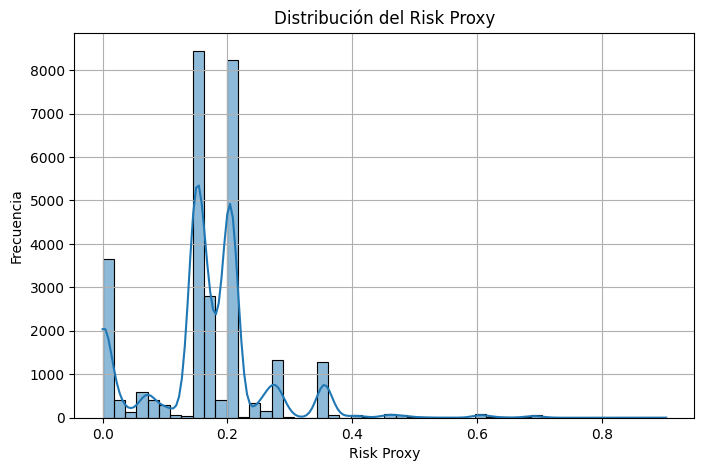

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df["risk_proxy"], bins=50, kde=True)
plt.title("Distribución del Risk Proxy")
plt.xlabel("Risk Proxy")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

- Cola larga hacia valores altos: anomalías fuertes
- Mayor masa en valores bajos: comportamiento normal

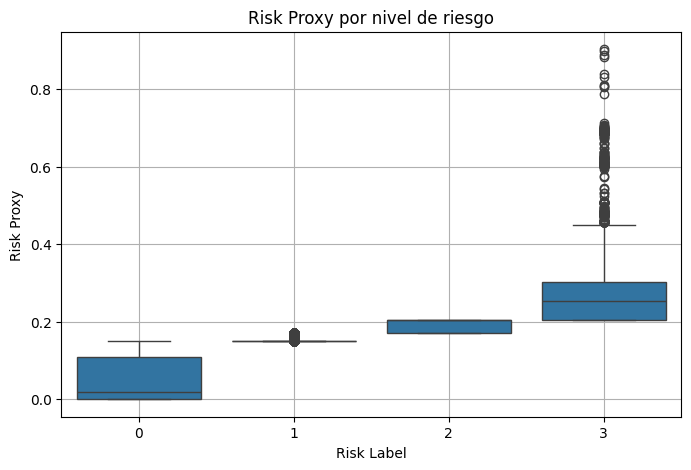

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x="risk_label", y="risk_proxy", data=df)
plt.title("Risk Proxy por nivel de riesgo")
plt.xlabel("Risk Label")
plt.ylabel("Risk Proxy")
plt.grid()
plt.show()

Ranking de anomalías

In [38]:
top_segments = df.sort_values("risk_proxy", ascending=False).head(20)

display(top_segments[[
    "trajectory_global",
    "risk_proxy",
    "risk_label",
    "hybrid_score",
    "rule_score_norm",
    "cluster_kmeans"
]])

,trajectory_global,risk_proxy,risk_label,hybrid_score,rule_score_norm,cluster_kmeans
404,367712660_0,0.903529,3,0.459785,1.000000,6.0
14377,367615130_0,0.899029,3,0.451624,1.000000,1.0
27869,367702380_1,0.889737,3,0.434772,1.000000,1.0
14233,367518250_7,0.882663,3,0.421943,1.000000,1.0
20000,368351530_0,0.840505,3,0.464916,0.853659,1.0
19508,367757130_0,0.832733,3,0.450821,0.853659,1.0
27731,257682000_0,0.809879,3,0.409375,0.853659,1.0
9726,367468610_0,0.808227,3,0.406379,0.853659,0.0
2539,367695280_0,0.806176,3,0.402658,0.853659,1.0
27803,368188310_0,0.786835,3,0.397441,0.817073,1.0


Ranking de trayecorias anómalas

In [39]:
traj_risk = (
    df.groupby("trajectory_global")["risk_proxy"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_traj = traj_risk.head(20)
display(top_traj)

,trajectory_global,risk_proxy
0,368288630_0,0.606128
1,338203000_1,0.603068
2,367081770_5,0.601554
3,367474720_8,0.507969
4,368341970_1,0.457855
5,367671820_1,0.457812
6,366999464_0,0.415030
7,367446540_3,0.410426
8,319220600_2,0.404254
9,338499688_0,0.398174


## LTR

A modo de validación

In [40]:
feature_cols = [
    'speed_mean', 'speed_max', 'delta_course_mean', 'delta_course_max',
    'turning_rate_mean', 'turning_rate_max', 'course_instability',
    'distance_km', 'duration', 'ais_gap'
]

X = df[feature_cols].fillna(0)
y = df["risk_proxy"]

Se opta por un enfoque de regresión en lugar de clasificación o técnicas formales de Learning to Rank, dado que el risk_proxy constituye una variable continua que representa un nivel de riesgo agregado.

El objetivo del experimento no es predecir clases discretas, sino evaluar si la función de riesgo definida puede ser aproximada a partir de las características originales del segmento. En este contexto, la regresión permite modelar directamente la estructura continua del riesgo y analizar la capacidad de generalización del ranking obtenido.

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

y_pred = model.predict(X)

print("R2 score:", r2_score(y, y_pred))

R2 score: 0.9458114387379299


El modelo explica el 94% de la varianza, lo que indica que el risk_proxy puede ser explicado en gran medida a partir de las características del segmento. Esto sugiere que la función de riesgo tiene una estructura coherente y no es arbitraria.

## Comparación de rankings

In [42]:
df["predicted_risk"] = y_pred

top_real = df.sort_values("risk_proxy", ascending=False).head(20)
top_pred = df.sort_values("predicted_risk", ascending=False).head(20)

print("Top real vs predicted overlap:")
overlap = set(top_real.index).intersection(set(top_pred.index))
print(f"{len(overlap)} / 20 coinciden")

Top real vs predicted overlap:
13 / 20 coinciden


El solapamiento entre el top real y el top predicho aumenta de 6/20 a 13/20 al utilizar el dataset ampliado. Esto indica que la señal de riesgo definida mediante `risk_proxy` es más aprendible cuando el modelo dispone de un conjunto de candidatos más amplio y diverso.

Aunque el modelo no reproduce perfectamente el ranking, consigue recuperar 13 de los 20 segmentos más prioritarios, lo que sugiere que las variables utilizadas contienen información relevante para explicar la criticidad relativa de los eventos.

Este resultado refuerza la decisión de construir el dataset de ranking a partir de un conjunto amplio de candidatos, en lugar de limitarse únicamente a las anomalías finales más filtradas.

## Guardado

Al finalizar el análisis de riesgo, se guardan varias salidas para facilitar su reutilización en fases posteriores del proyecto.

En primer lugar, se almacena el dataset completo con los scores de riesgo (`risk_proxy`), etiquetas ordinales (`risk_label`) y posiciones de ranking tanto globales como por trayectoria. Esto permite conservar la salida completa del Notebook 7.

Además, se generan subconjuntos específicos con los segmentos de mayor riesgo global y los segmentos más relevantes dentro de cada trayectoria. Estos archivos están pensados para alimentar un simulador o herramienta de visualización, de forma que puedan inspeccionarse espacial y temporalmente los casos priorizados por el sistema.

De este modo, el ranking no queda únicamente como resultado numérico, sino que se conecta con una fase posterior de análisis visual e interpretación operativa.

In [43]:
import os
import json
import pandas as pd
import numpy as np

results_dir = "/content/drive/MyDrive/TFG/data_processed/results/risk_ranking/"
os.makedirs(results_dir, exist_ok=True)

df_save = df.copy()

# Si existe predicción del modelo de regresión, la añadimos
try:
    df_save.loc[X_test.index, "risk_proxy_pred"] = y_pred
    print("Predicciones añadidas correctamente")
except:
    print("No se han añadido predicciones (modelo no ejecutado en esta sesión)")

# Ranking global por risk_proxy real
df_save["risk_rank_global"] = df_save["risk_proxy"].rank(
    ascending=False,
    method="first"
).astype(int)

# Ranking dentro de cada trayectoria
group_col = "trajectory_global" if "trajectory_global" in df_save.columns else "trajectory_id"

df_save["risk_rank_within_trajectory"] = (
    df_save.groupby(group_col)["risk_proxy"]
    .rank(ascending=False, method="first")
    .astype(int)
)

# Guardado completo
full_path = os.path.join(results_dir, "notebook7_risk_ranking_results.csv")
df_save.to_csv(full_path, index=False)

print("Guardado:", full_path)
print("Shape:", df_save.shape)

No se han añadido predicciones (modelo no ejecutado en esta sesión)
Guardado: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/notebook7_risk_ranking_results.csv
Shape: (29141, 36)


Guardado por anomalías

In [44]:
top_global = df_save.sort_values("risk_proxy", ascending=False).head(100)

top_global_path = os.path.join(results_dir, "top_100_global_risk_segments.csv")
top_global.to_csv(top_global_path, index=False)

print("Top 100 global guardado en:", top_global_path)

display(top_global.head(20))

Top 100 global guardado en: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/top_100_global_risk_segments.csv


,MMSI,trajectory_id,segment_id,ae_score,lof_score,hybrid_score,hybrid_score_norm,rule_score_raw,rule_score_norm,potential_real_anomaly,is_synthetic,anomaly_type,ship_type,hybrid_context_pred,cluster_kmeans,cluster_hdbscan,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag,risk_proxy,risk_label,trajectory_global,predicted_risk,risk_rank_global,risk_rank_within_trajectory
404,367712660,0,951543,1.152985,2.283014,0.459785,0.724370,8.2,1.000000,1.0,1,speed_anomaly,Passenger,1,6.0,1.0,0.000000,0.000000,83.342857,179.0,0.837251,1.808081,95.657143,0.048239,840.0,3.103527,1,1,1,1,0.903529,3,367712660_0,0.680019,1,1
14377,367615130,0,859341,1.116764,2.579953,0.451624,0.711512,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,69.800000,168.6,1.254838,4.323077,98.800000,0.005882,888.0,2.657658,1,1,1,0,0.899029,3,367615130_0,0.705466,2,1
27869,367702380,1,936205,1.041970,2.434860,0.434772,0.684962,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.639026,4.600988,64.871429,175.3,0.687586,1.638318,110.428571,0.105700,879.0,3.112754,1,1,1,0,0.889737,3,367702380_1,0.667384,3,1
14233,367518250,7,770925,0.985032,2.119142,0.421943,0.664751,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.742356,1.299123,49.062500,177.2,0.569360,2.243038,128.137500,0.022975,730.0,2.316378,1,1,1,0,0.882663,3,367518250_7,0.702774,4,1
20000,368351530,0,1332279,1.305655,2.365759,0.464916,0.732453,7.0,0.853659,1.0,1,speed_anomaly,Service,1,1.0,-1.0,0.057484,0.134129,118.333333,168.6,1.224391,2.028571,50.266667,0.000000,810.0,3.093548,1,1,1,0,0.840505,3,368351530_0,0.675321,5,1
19508,367757130,0,984555,1.243097,2.217186,0.450821,0.710247,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,106.555556,164.8,1.409475,2.354286,58.244444,0.011969,878.0,3.143460,1,1,1,0,0.832733,3,367757130_0,0.614581,6,1
27731,257682000,0,42082,1.059150,2.022734,0.409375,0.644950,7.0,0.853659,1.0,1,speed_anomaly,Tanker,1,1.0,-1.0,0.127583,0.255165,66.775000,137.6,0.843467,1.994203,70.825000,0.003341,698.0,2.145275,1,1,1,0,0.809879,3,257682000_0,0.648917,7,1
9726,367468610,0,717350,1.045853,2.173448,0.406379,0.640230,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,0.0,-1.0,0.046515,0.116288,55.625000,87.1,0.527559,1.226761,31.475000,0.005801,721.0,2.221519,1,1,1,0,0.808227,3,367468610_0,0.646274,8,1
2539,367695280,0,929628,1.029343,2.052493,0.402658,0.634369,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.700550,3.853022,71.585714,146.4,0.726580,1.644944,74.814286,0.075586,757.0,2.143727,1,1,1,0,0.806176,3,367695280_0,0.604684,9,1
27803,368188310,0,1194711,1.038663,1.929942,0.397441,0.626150,6.7,0.817073,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.128423,0.433429,53.300000,138.2,0.760489,2.586275,84.900000,0.021573,582.0,5.093960,1,1,1,0,0.786835,3,368188310_0,0.547252,10,1


Guardar por trayectoria

In [45]:
top_per_trajectory = (
    df_save.sort_values("risk_proxy", ascending=False)
    .groupby(group_col)
    .head(10)
    .reset_index(drop=True)
)

top_traj_path = os.path.join(results_dir, "top_10_segments_per_trajectory.csv")
top_per_trajectory.to_csv(top_traj_path, index=False)

print("Top por trayectoria guardado en:", top_traj_path)

display(top_per_trajectory.head(30))

Top por trayectoria guardado en: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/top_10_segments_per_trajectory.csv


,MMSI,trajectory_id,segment_id,ae_score,lof_score,hybrid_score,hybrid_score_norm,rule_score_raw,rule_score_norm,potential_real_anomaly,is_synthetic,anomaly_type,ship_type,hybrid_context_pred,cluster_kmeans,cluster_hdbscan,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag,risk_proxy,risk_label,trajectory_global,predicted_risk,risk_rank_global,risk_rank_within_trajectory
0,367712660,0,951543,1.152985,2.283014,0.459785,0.724370,8.2,1.000000,1.0,1,speed_anomaly,Passenger,1,6.0,1.0,0.000000,0.000000,83.342857,179.0,0.837251,1.808081,95.657143,0.048239,840.0,3.103527,1,1,1,1,0.903529,3,367712660_0,0.680019,1,1
1,367615130,0,859341,1.116764,2.579953,0.451624,0.711512,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,69.800000,168.6,1.254838,4.323077,98.800000,0.005882,888.0,2.657658,1,1,1,0,0.899029,3,367615130_0,0.705466,2,1
2,367702380,1,936205,1.041970,2.434860,0.434772,0.684962,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.639026,4.600988,64.871429,175.3,0.687586,1.638318,110.428571,0.105700,879.0,3.112754,1,1,1,0,0.889737,3,367702380_1,0.667384,3,1
3,367518250,7,770925,0.985032,2.119142,0.421943,0.664751,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.742356,1.299123,49.062500,177.2,0.569360,2.243038,128.137500,0.022975,730.0,2.316378,1,1,1,0,0.882663,3,367518250_7,0.702774,4,1
4,368351530,0,1332279,1.305655,2.365759,0.464916,0.732453,7.0,0.853659,1.0,1,speed_anomaly,Service,1,1.0,-1.0,0.057484,0.134129,118.333333,168.6,1.224391,2.028571,50.266667,0.000000,810.0,3.093548,1,1,1,0,0.840505,3,368351530_0,0.675321,5,1
5,367757130,0,984555,1.243097,2.217186,0.450821,0.710247,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,106.555556,164.8,1.409475,2.354286,58.244444,0.011969,878.0,3.143460,1,1,1,0,0.832733,3,367757130_0,0.614581,6,1
6,257682000,0,42082,1.059150,2.022734,0.409375,0.644950,7.0,0.853659,1.0,1,speed_anomaly,Tanker,1,1.0,-1.0,0.127583,0.255165,66.775000,137.6,0.843467,1.994203,70.825000,0.003341,698.0,2.145275,1,1,1,0,0.809879,3,257682000_0,0.648917,7,1
7,367468610,0,717350,1.045853,2.173448,0.406379,0.640230,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,0.0,-1.0,0.046515,0.116288,55.625000,87.1,0.527559,1.226761,31.475000,0.005801,721.0,2.221519,1,1,1,0,0.808227,3,367468610_0,0.646274,8,1
8,367695280,0,929628,1.029343,2.052493,0.402658,0.634369,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.700550,3.853022,71.585714,146.4,0.726580,1.644944,74.814286,0.075586,757.0,2.143727,1,1,1,0,0.806176,3,367695280_0,0.604684,9,1
9,368188310,0,1194711,1.038663,1.929942,0.397441,0.626150,6.7,0.817073,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.128423,0.433429,53.300000,138.2,0.760489,2.586275,84.900000,0.021573,582.0,5.093960,1,1,1,0,0.786835,3,368188310_0,0.547252,10,1


In [46]:
summary = {
    "n_rows": int(df_save.shape[0]),
    "n_columns": int(df_save.shape[1]),
    "group_col": group_col,
    "n_groups": int(df_save[group_col].nunique()),
    "risk_label_distribution": df_save["risk_label"].value_counts().sort_index().to_dict(),
    "risk_proxy_min": float(df_save["risk_proxy"].min()),
    "risk_proxy_max": float(df_save["risk_proxy"].max()),
    "risk_proxy_mean": float(df_save["risk_proxy"].mean())
}

if "r2" in globals():
    summary["r2_score"] = float(r2)

summary_path = os.path.join(results_dir, "notebook7_summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Resumen guardado en:", summary_path)
summary

Resumen guardado en: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/notebook7_summary.json


{'n_rows': 29141,
 'n_columns': 36,
 'group_col': 'trajectory_global',
 'n_groups': 2904,
 'risk_label_distribution': {0: 7286, 1: 7285, 2: 7285, 3: 7285},
 'risk_proxy_min': 3.158916963769971e-07,
 'risk_proxy_max': 0.9035294866574152,
 'risk_proxy_mean': 0.16784590400221258}

### Para el simulador

In [47]:
simulator_cols = [
    "MMSI",
    "trajectory_id",
    "segment_id",
    "trajectory_global",
    "risk_proxy",
    "risk_label",
    "risk_rank_global",
    "risk_rank_within_trajectory",
    "ae_score",
    "lof_score",
    "hybrid_score",
    "rule_score_norm",
    "potential_real_anomaly",
    "cluster_kmeans",
    "cluster_hdbscan",
    "ship_type",
    "anomaly_type"
]

simulator_cols = [c for c in simulator_cols if c in df_save.columns]

simulator_df = df_save[simulator_cols].copy()

simulator_path = os.path.join(results_dir, "simulator_risk_segments.csv")
simulator_df.to_csv(simulator_path, index=False)

print("Dataset para simulador guardado en:", simulator_path)
print("Shape:", simulator_df.shape)

display(simulator_df.head())

Dataset para simulador guardado en: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/simulator_risk_segments.csv
Shape: (29141, 17)


,MMSI,trajectory_id,segment_id,trajectory_global,risk_proxy,risk_label,risk_rank_global,risk_rank_within_trajectory,ae_score,lof_score,hybrid_score,rule_score_norm,potential_real_anomaly,cluster_kmeans,cluster_hdbscan,ship_type,anomaly_type
0,367689040,1,923622,367689040_1,0.170827,2,14407,7,0.000082,1.071137,0.060992,0.304878,NaN,NaN,NaN,Service,normal
1,368161380,0,1170073,368161380_0,0.200389,2,11681,4,1.062951,3.388275,0.263889,0.121951,0.0,0.0,-1.0,Special_Craft,speed_anomaly
2,366838630,1,370317,366838630_1,0.355360,3,821,4,0.000492,1.021555,0.126938,0.634146,0.0,6.0,4.0,Passenger,normal
3,367030830,6,505747,367030830_6,0.150376,1,16485,15,0.000468,1.004585,0.053762,0.268293,NaN,NaN,NaN,Special_Craft,normal
4,367480130,0,730307,367480130_0,0.018650,0,25457,6,0.150122,298.980127,0.033823,0.000000,NaN,NaN,NaN,Special_Craft,loitering_like


In [48]:
# Casos recomendados para visualizar en el simulador
# Top riesgo global + top dentro de cada trayectoria

simulator_top = pd.concat([
    df_save.sort_values("risk_proxy", ascending=False).head(50),
    top_per_trajectory
]).drop_duplicates(subset=[c for c in ["MMSI", "trajectory_id", "segment_id"] if c in df_save.columns])

simulator_top_path = os.path.join(results_dir, "simulator_top_cases_to_visualize.csv")
simulator_top.to_csv(simulator_top_path, index=False)

print("Casos recomendados para visualizar guardados en:", simulator_top_path)
print("Shape:", simulator_top.shape)

display(simulator_top.head(20))

Casos recomendados para visualizar guardados en: /content/drive/MyDrive/TFG/data_processed/results/risk_ranking/simulator_top_cases_to_visualize.csv
Shape: (15639, 36)


,MMSI,trajectory_id,segment_id,ae_score,lof_score,hybrid_score,hybrid_score_norm,rule_score_raw,rule_score_norm,potential_real_anomaly,is_synthetic,anomaly_type,ship_type,hybrid_context_pred,cluster_kmeans,cluster_hdbscan,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,course_instability,distance_km,duration,ais_gap,slow_motion,high_speed_flag,low_distance_flag,erratic_motion_flag,risk_proxy,risk_label,trajectory_global,predicted_risk,risk_rank_global,risk_rank_within_trajectory
404,367712660,0,951543,1.152985,2.283014,0.459785,0.724370,8.2,1.000000,1.0,1,speed_anomaly,Passenger,1,6.0,1.0,0.000000,0.000000,83.342857,179.0,0.837251,1.808081,95.657143,0.048239,840.0,3.103527,1,1,1,1,0.903529,3,367712660_0,0.680019,1,1
14377,367615130,0,859341,1.116764,2.579953,0.451624,0.711512,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,69.800000,168.6,1.254838,4.323077,98.800000,0.005882,888.0,2.657658,1,1,1,0,0.899029,3,367615130_0,0.705466,2,1
27869,367702380,1,936205,1.041970,2.434860,0.434772,0.684962,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.639026,4.600988,64.871429,175.3,0.687586,1.638318,110.428571,0.105700,879.0,3.112754,1,1,1,0,0.889737,3,367702380_1,0.667384,3,1
14233,367518250,7,770925,0.985032,2.119142,0.421943,0.664751,8.2,1.000000,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.742356,1.299123,49.062500,177.2,0.569360,2.243038,128.137500,0.022975,730.0,2.316378,1,1,1,0,0.882663,3,367518250_7,0.702774,4,1
20000,368351530,0,1332279,1.305655,2.365759,0.464916,0.732453,7.0,0.853659,1.0,1,speed_anomaly,Service,1,1.0,-1.0,0.057484,0.134129,118.333333,168.6,1.224391,2.028571,50.266667,0.000000,810.0,3.093548,1,1,1,0,0.840505,3,368351530_0,0.675321,5,1
19508,367757130,0,984555,1.243097,2.217186,0.450821,0.710247,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.000000,0.000000,106.555556,164.8,1.409475,2.354286,58.244444,0.011969,878.0,3.143460,1,1,1,0,0.832733,3,367757130_0,0.614581,6,1
27731,257682000,0,42082,1.059150,2.022734,0.409375,0.644950,7.0,0.853659,1.0,1,speed_anomaly,Tanker,1,1.0,-1.0,0.127583,0.255165,66.775000,137.6,0.843467,1.994203,70.825000,0.003341,698.0,2.145275,1,1,1,0,0.809879,3,257682000_0,0.648917,7,1
9726,367468610,0,717350,1.045853,2.173448,0.406379,0.640230,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,0.0,-1.0,0.046515,0.116288,55.625000,87.1,0.527559,1.226761,31.475000,0.005801,721.0,2.221519,1,1,1,0,0.808227,3,367468610_0,0.646274,8,1
2539,367695280,0,929628,1.029343,2.052493,0.402658,0.634369,7.0,0.853659,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.700550,3.853022,71.585714,146.4,0.726580,1.644944,74.814286,0.075586,757.0,2.143727,1,1,1,0,0.806176,3,367695280_0,0.604684,9,1
27803,368188310,0,1194711,1.038663,1.929942,0.397441,0.626150,6.7,0.817073,1.0,1,speed_anomaly,Special_Craft,1,1.0,-1.0,0.128423,0.433429,53.300000,138.2,0.760489,2.586275,84.900000,0.021573,582.0,5.093960,1,1,1,0,0.786835,3,368188310_0,0.547252,10,1
